In [1]:
import gymnasium as gym
import register_env

env = gym.make("Snake-v0", render_mode='matplotlib')

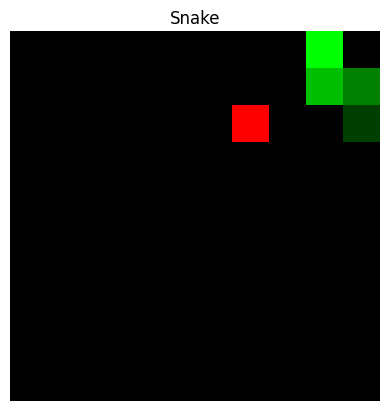

array([1., 0., 0., 0.], dtype=float32)

In [5]:
env.reset()

for i in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    if terminated or truncated:
        env.reset()

obs[-4:]

In [6]:
from stable_baselines3.common.env_checker import check_env

check_env(env)

In [ ]:
import gymnasium as gym
import register_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

def make_env():
    return gym.make("Snake-v0", render_mode='ascii')   # turn off render during training

vec_env = DummyVecEnv([make_env])       # parallel on 1 CPU (stable)

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    tensorboard_log="./snake_logs/",
    verbose=1
)

%load_ext tensorboard
%tensorboard --logdir snake_logs

model.learn(total_timesteps=200_000)

model.save("ppo_snake")

Using cpu device


Reusing TensorBoard on port 6006 (pid 33884), started 0:07:59 ago. (Use '!kill 33884' to kill it.)

Logging to ./snake_logs/PPO_3
-----------------------------
| time/              |      |
|    fps             | 804  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 575         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009676093 |
|    clip_fraction        | 0.0425      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -1.13       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0579     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0101     |
|    value_loss           | 0.0292      |
-----------------------------------------
----

KeyboardInterrupt: 

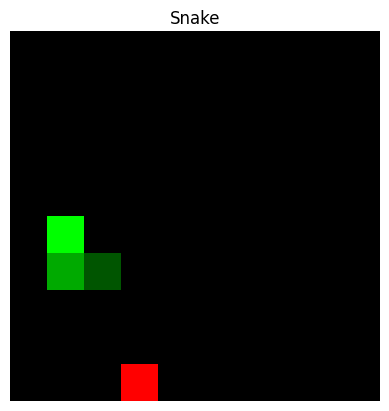

In [6]:
watch_env = gym.make("Snake-v0", render_mode='matplotlib')
obs, _ = watch_env.reset()

for _ in range(1000):
    action, _ = model.predict(obs)
    obs, reward, done, truncated, info = watch_env.step(action)
    watch_env.render()
    if done:
        obs, _ = watch_env.reset()
